# Determining Age of Open Cluster M67 via BV Photometry and Isochrone Fitting Lab
## Data Reduction and Data Analysis

### Author ID: 115188789, 114956855, 
#### Department of Physics and Astronomy, Stony Brook University, Stony Brook, NY 11794, USA

Open star clusters are groups of stars that all formed from the same gas cloud at the same time. Because every star in the cluster shares the same age and distance from Earth, we can use their collective brightness and colors to figure out how old the cluster is. We propose to image the open cluster M67 (NGC 2682) in two filters (B and V) using the Mt. Stony Brook 14-inch telescope. From these images we will measure the brightness and color of hundreds of cluster stars and build a color–magnitude diagram (CMD), a plot of stellar brightness versus color. We will then compare the shape of the CMD to computer-generated stellar evolution models called isochrones, which predict what a cluster of a given age should look like. M67 is an ideal target because its stars are at convenient brightnesses for our telescope (V ≈ 10–16), it is well-placed in the sky, and its∼4 Gyr age produces a clear, distinctive CMD shape that makes age determination straightforward. Our quantitative goal is to determine the cluster age to within ±0.5 Gyr and compare our result to the accepted literature value.


In [ ]:
### for array operations
import numpy as np

### for plotting
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
#matplotlib.rcParams['figure.figsize'] = [10, 3.5]

### for operations on FITS images
from astropy.io import fits
from astropy.modeling import models
from astropy import units as u
#from astropy.constants import c, h, k_B


### statistics functions
from scipy import stats
from scipy.stats import norm
from scipy.signal import find_peaks
from scipy import ndimage

### for accessing directors
import os
import glob

### for calculations
import math

### for aligning images in the Pretty Picture Section of the lab
import skimage

In [2]:
### Method to write & save new FITS files
def save_as_fits_file(pathname, arr):
    # before we write the file, we make sure it does not exist, and if it does, we delete it (DANGEROUS!)
    try:
        os.remove(pathname)
    except OSError:
        pass
    
    newhdu = fits.PrimaryHDU(data=arr)
    newhdu.writeto(pathname)

### Method to open and store all data from FITS frames within a folder in an array
def get_frames_from_folder(pathname):
    dir_list = os.listdir(pathname)  # List all filenames in directory
    frames = []
    for file in dir_list:
        path = pathname + "/" + file
        if os.path.isfile(path):
            frame = fits.open(path)
            frames.append(frame[0].data)
            frame.close()
    return frames

### Data Reduction - Reducing Raw Images
Subtract dark frames, apply flat-field correction.

First, we will get the master images for the dark frames and flat frames:

In [3]:
# Get Master Dark Frames
mdf_2s = np.median(get_frames_from_folder('Data/Darks/2s'), axis=0)
mdf_4s = np.median(get_frames_from_folder('Data/Darks/4s'), axis=0)
mdf_17s = np.median(get_frames_from_folder('Data/Darks/17s'), axis=0)
mdf_45s = np.median(get_frames_from_folder('Data/Darks/45s'), axis=0)
save_as_fits_file('Data/Results/mdf/mdf_2s.fits', mdf_2s)
save_as_fits_file('Data/Results/mdf/mdf_4s.fits', mdf_4s)
save_as_fits_file('Data/Results/mdf/mdf_17s.fits', mdf_17s)
save_as_fits_file('Data/Results/mdf/mdf_45s.fits', mdf_45s)


# Just for presentation:
frame = fits.open('Data/M67/B 45s/-B-45s-0C-20260409-020807.fits')
example = frame[0].data
frame.close()
save_as_fits_file('Data/Results/mdf/mdf subtracted m67B.fits', example - mdf_45s)


# Get Master Flat Frames and subtract respective dark frames
mff_R = np.median(get_frames_from_folder('Data/Flats/2s'), axis=0) - mdf_2s
mff_R = mff_R / np.mean(mff_R)
mff_V = np.median(get_frames_from_folder('Data/Flats/4s'), axis=0) - mdf_4s
mff_V = mff_V / np.mean(mff_V)
mff_B = np.median(get_frames_from_folder('Data/Flats/17s'), axis=0) - mdf_17s
mff_B = mff_B / np.mean(mff_B)
save_as_fits_file('Data/Results/mff/mff_R_2s.fits', mff_R)
save_as_fits_file('Data/Results/mff/mff_V_4s.fits', mff_V)
save_as_fits_file('Data/Results/mff/mff_B_17s.fits', mff_B)

# Get the median Science Images (KEEP THIS TO SHOW UNALIGNED IMAGES FOR PRESENTATION)
m67_B = np.median(get_frames_from_folder('Data/M67/B 45s'), axis=0)
m67_V = np.median(get_frames_from_folder('Data/M67/V 45s'), axis=0)
save_as_fits_file('Data/Results/m67/unaligned_m67_B.fits', m67_B)
save_as_fits_file('Data/Results/m67/unaligned_m67_V.fits', m67_V)

The flat field dimensions and the dimensions of every other frame diverge:

Flatfield: 261,390 (y, x)
Science & Dark Frames: 262,392 (y, x)

Because the flat-field images are different dimensions by 2 x 1 pixel, we crop the images so that they align. The positioning of the crop was decided by manually matching a warm pixel in the dark frames with a warm pixel in the flat field to understand how they should align. The pixel was at x = 144 and y = 99 in the dark frame and at x= 142 and y=99 in the flat field frame. Therefore, the first two columns of the science frames must be removed. Since the y position of the warm pixel does not change between frames, the flatfield must be missing the last row (missing y=262), so the last row of the science frames must be cropped out.

In [4]:
# Get science frames across B and V filter, subtract master dark frames, and correct for sensitivity
m67_B_frames = get_frames_from_folder('Data/M67/B 45s') - mdf_45s
m67_B_frames = np.delete(m67_B_frames, -1, 1)
m67_B_frames = np.delete(m67_B_frames, [0,1], 2)
m67_B_frames = m67_B_frames / mff_B

m67_V_frames = get_frames_from_folder('Data/M67/V 45s') - mdf_45s
m67_V_frames = np.delete(m67_V_frames, -1, 1)
m67_V_frames = np.delete(m67_V_frames, [0,1], 2)
m67_V_frames = m67_V_frames / mff_V

Next, we align each of the frames in the B and V filter and then align the two median images that result from them.

In [5]:

### Aligning the frames to the first frame in the list.
def align_frame(reference_image, moving_image, ref_mask):
    shift_vector, error, _, = skimage.registration.phase_cross_correlation(
        reference_image,
        moving_image,
        #reference_mask=ref_mask,
    )
    shifted_image = ndimage.shift(moving_image, shift_vector)
    #print(shift_vector)
    return shifted_image

def get_aligned_frames(frames, threshold):
    # Mask for the reference image in order to assist the Phase Cross Correlation function, threshhold decided manually.
    # Threshhold decides the minimum count of a given pixel to not be masked over.
    reference_frame = frames[0]
    ref_mask = np.copy(reference_frame)
    ref_mask[ref_mask < threshold] = 0
    aligned_frames = []
    for frame in frames:
        aligned_frames.append(align_frame(reference_frame, frame, ref_mask))
    return aligned_frames
 
aligned_m67_B_frames = get_aligned_frames(m67_B_frames, 1) 
aligned_m67_V_frames = get_aligned_frames(m67_V_frames, 1) 

m67_B_median = np.median(aligned_m67_B_frames, axis=0)
m67_V_median = np.median(aligned_m67_V_frames, axis=0)
m67_B_mean = np.mean(aligned_m67_B_frames, axis=0)
m67_V_mean = np.mean(aligned_m67_V_frames, axis=0)

save_as_fits_file('Data/Results/m67/median_m67_B.fits', m67_B_median)
save_as_fits_file('Data/Results/m67/mean_m67_B.fits', m67_B_mean)
save_as_fits_file('Data/Results/m67/median_m67_V.fits', m67_V_median)
save_as_fits_file('Data/Results/m67/mean_m67_V.fits', m67_V_mean)

# Crop Aligned Frames to remove gradient
cropped_m67_B_mean = m67_B_mean[10:, 36:]
cropped_m67_V_mean = m67_V_mean[:249, :353]
save_as_fits_file('Data/Results/m67/cropped_mean_m67_B.fits', cropped_m67_B_mean)
save_as_fits_file('Data/Results/m67/cropped_mean_m67_V.fits', cropped_m67_V_mean)



aligned_m67_B_median, aligned_m67_V_median = get_aligned_frames([m67_B_median, m67_V_median], 1)
aligned_m67_B_mean, aligned_m67_V_mean = get_aligned_frames([m67_B_mean, m67_V_mean], 1)

save_as_fits_file('Data/Results/m67/aligned_m67_B_median.fits', aligned_m67_B_median)
save_as_fits_file('Data/Results/m67/aligned_m67_V_median.fits', aligned_m67_V_median)
save_as_fits_file('Data/Results/m67/aligned_m67_B_mean.fits', aligned_m67_B_mean)
save_as_fits_file('Data/Results/m67/aligned_m67_V_mean.fits', aligned_m67_V_mean)

Cropping the images to include no empty pixels after alignment.

In [6]:
m67_B = aligned_m67_B_median[5:245, 25:]
m67_V = aligned_m67_V_median[5:245, 25:]

save_as_fits_file('Data/Results/m67/final_m67_B.fits', m67_B)
save_as_fits_file('Data/Results/m67/final_m67_V.fits', m67_V)

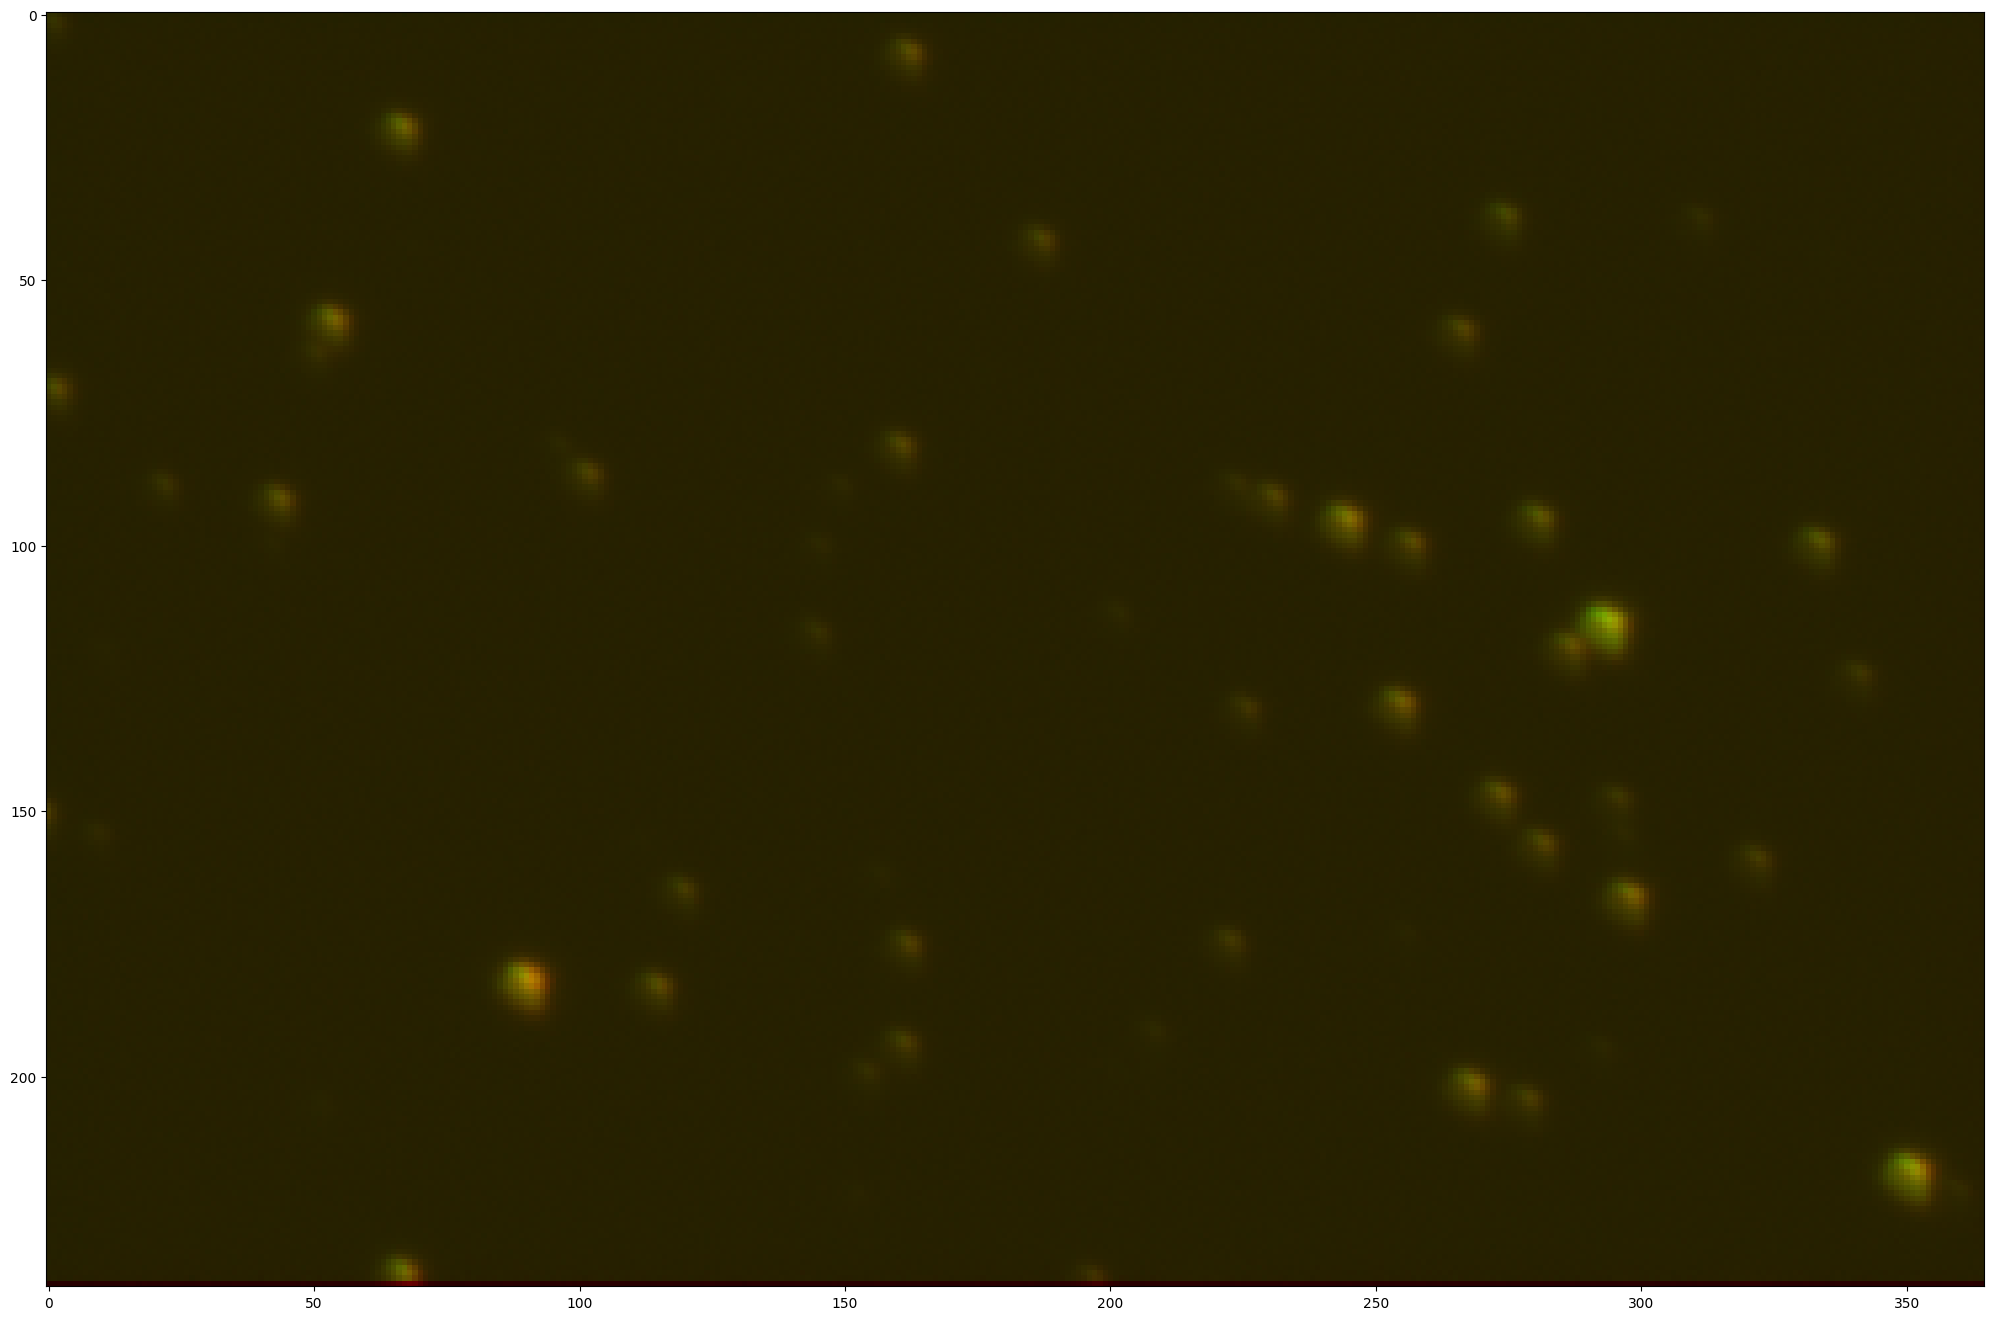

In [7]:

### Visual just to check alignment
from astropy.visualization import LogStretch, make_rgb, make_lupton_rgb, ManualInterval

zeroes = m67_B * 0

image = make_lupton_rgb(m67_B / np.max(m67_B) * 10, m67_V / np.max(m67_V) * 10, zeroes, stretch=4.8)
plt.figure(figsize=(25,25))
plt.imshow(image)


Star Detection - Identifying the stars through peak detection in the aligned frames.

In [8]:
from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clipped_stats
B_mean, B_median, B_std = sigma_clipped_stats(m67_B, sigma=3.0)
threshold = 5.0 * B_std
daofind = DAOStarFinder(threshold, fwhm=2.5, sharpness_range=(0.2, 1.5))

V_mean, V_median, V_std = sigma_clipped_stats(m67_V, sigma=3.0)

 id x_centroid y_centroid sharpness roundness1 roundness2 n_pixels  peak    flux    mag   daofind_mag
--- ---------- ---------- --------- ---------- ---------- -------- ------ -------- ------ -----------
  1     162.63       7.07      0.52       0.55      -0.03       25 252.08  3275.44  -8.79       -2.99
  2      67.18      21.12      0.57       0.50      -0.02       25 401.35  5171.96  -9.28       -3.42
  3     274.98      37.85      0.52       0.63       0.03       25 151.08  2019.86  -8.26       -2.38
  4     311.56      38.32      0.53       0.36      -0.33       25  41.17   555.78  -6.86       -0.91
  5     187.50      42.39      0.55       0.43      -0.04       25 155.67  2019.03  -8.26       -2.42
  6      54.03      57.45      0.54       0.60       0.05       25 451.83  5981.75  -9.44       -3.54
  7     266.72      59.31      0.58       0.51      -0.04       25 191.96  2448.46  -8.47       -2.61
  8     161.00      80.98      0.54       0.55      -0.10       25 203.77  2623.15

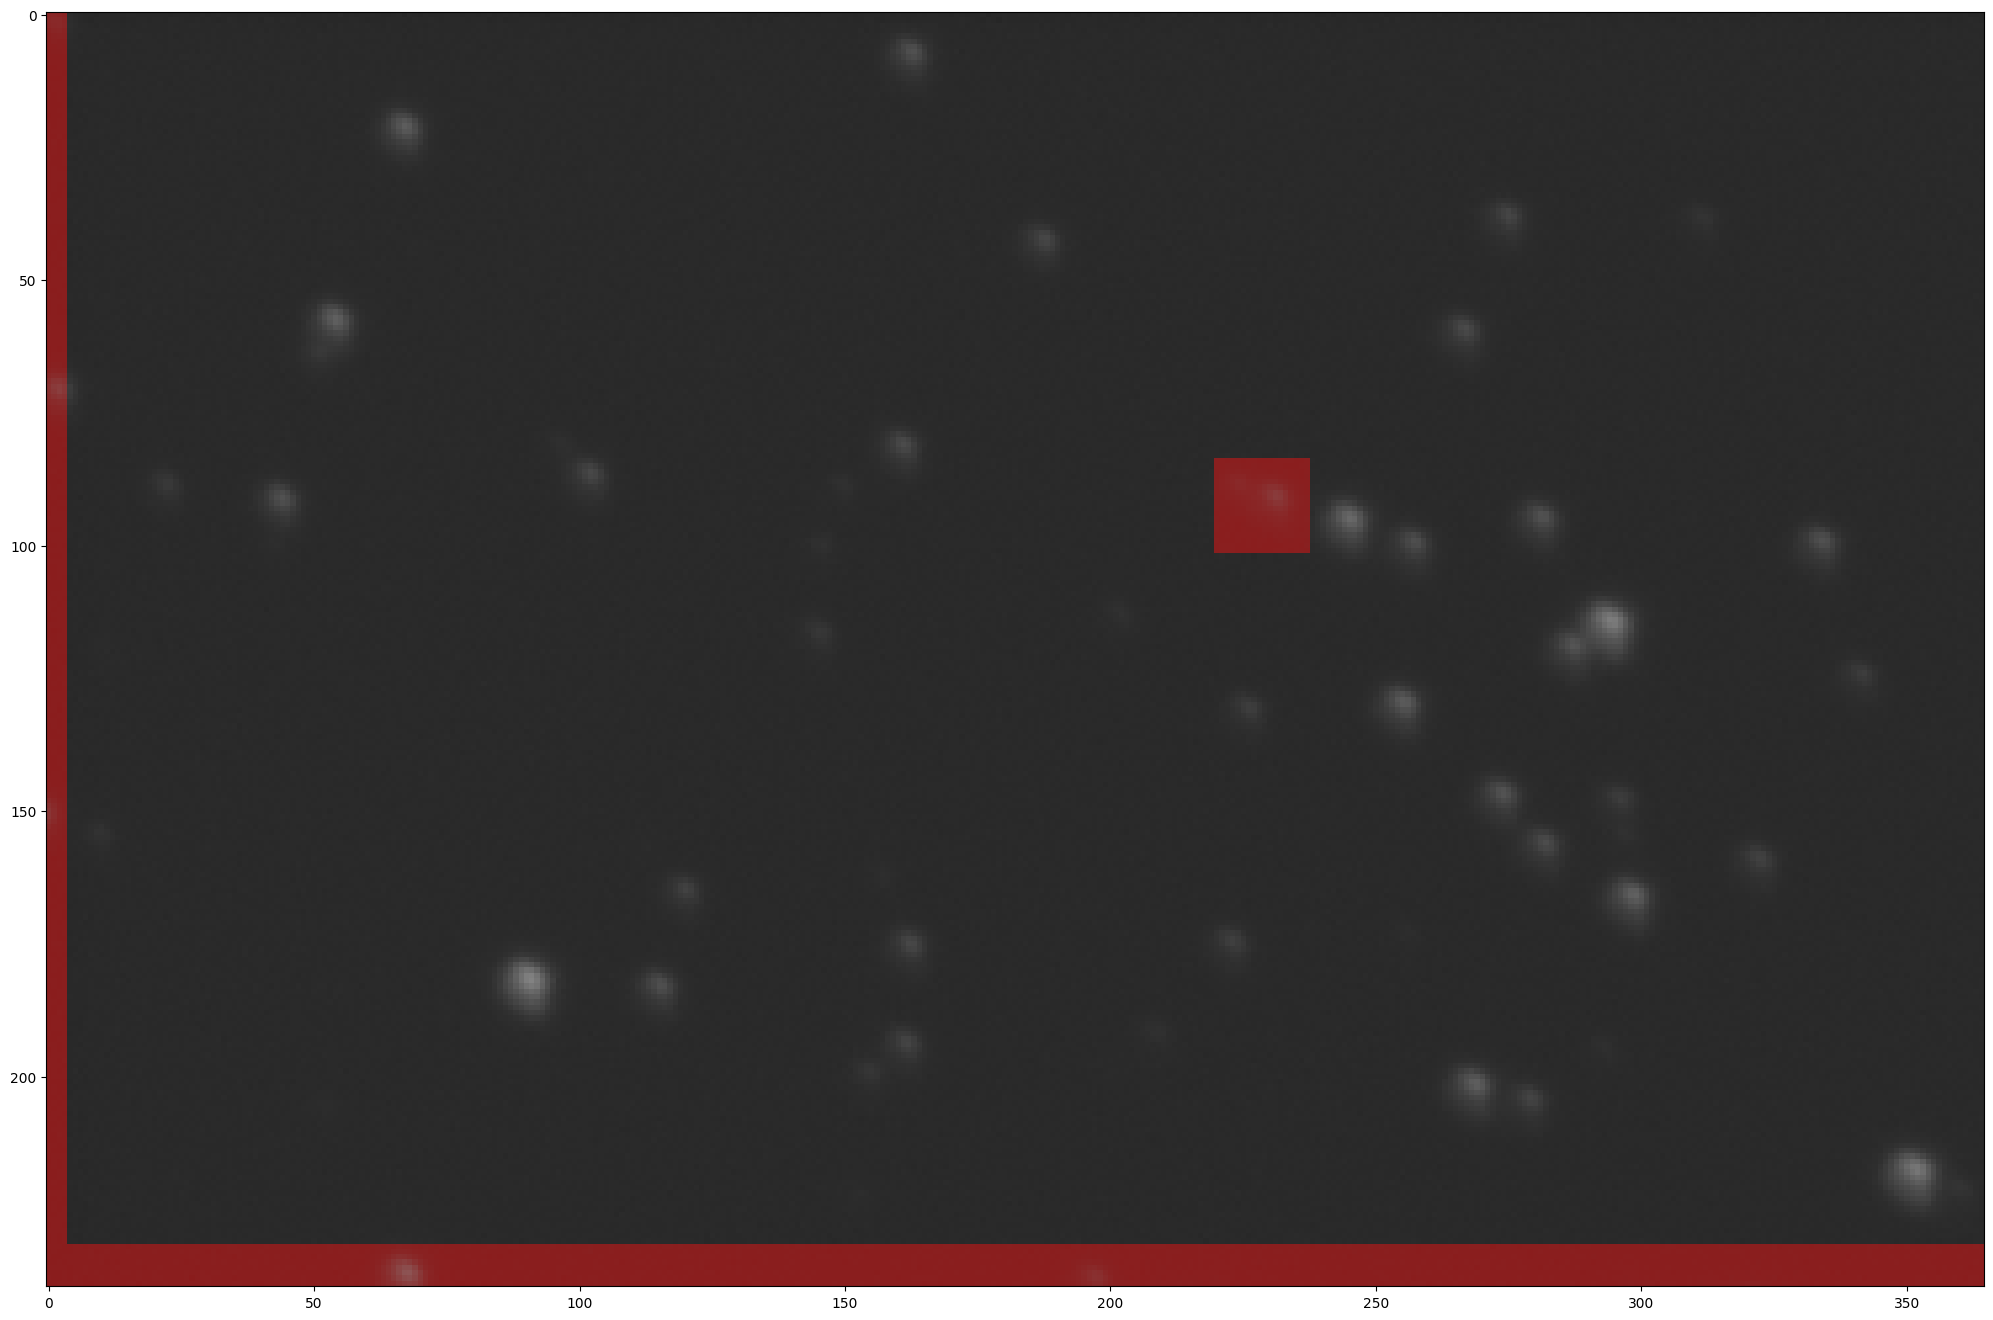

In [9]:
# Create mask regions where no stars are detected (for close stars and those along the edge) 
mask = np.zeros(m67_B.shape, dtype=bool)
mask_regions = [
    [232, m67_B.shape[0], 0, m67_B.shape[1]],
    [84, 102, 220, 238],
    [0, m67_B.shape[0],0, 4],
]
for region in mask_regions:
    mask[region[0]:region[1], region[2]:region[3]] = True

unmasked_value = m67_B / np.max(m67_B) * 4
image = make_lupton_rgb(unmasked_value + mask, unmasked_value, unmasked_value, stretch=1.5)
plt.figure(figsize=(25,25))
plt.gca().invert_yaxis()
plt.imshow(image)
plt.savefig('Data/Results/1_MaskedAreas.png', bbox_inches='tight')


sources = daofind(m67_B - B_median, mask=mask)
for col in sources.colnames:
    if col not in ('id', 'n_pixels'):
        sources[col].info.format = '%.2f'  # for consistent table output
sources.pprint(max_lines=20, max_width=150)

peak_test = np.copy(m67_B) - B_median
for source in sources:
    peak_test[int(source["y_centroid"])][int(source["x_centroid"])] = 40000

save_as_fits_file('Data/Results/m67/peak_test.fits', peak_test)

Aperture Photometry- Getting the sum of the total flux around each target with a Global Background Subtraction (Using the Median)

In [10]:
from photutils.aperture import CircularAperture, aperture_photometry
star_positions = list(map(lambda source : (int(source["x_centroid"]), int(source["y_centroid"])), sources))
aperture_radius = 6.0 # If we used a fixed radius
aperture = CircularAperture(star_positions, r=aperture_radius)

phot_table_B = aperture_photometry(m67_B - B_median, aperture)
phot_table_B['aperture_sum'].info.format = '%.8g'  # for consistent table output

phot_table_V = aperture_photometry(m67_V - V_median, aperture)
phot_table_V['aperture_sum'].info.format = '%.8g'  # for consistent table output

### Calculate the measurement uncertainty on the flux from the background + object shot noise 
### = \sqrt {N_{obj} + \sigma^2_{bkg}} where bkg is the std multiplied by the amount of pixels (the area)
aperture_area = np.pi * aperture_radius ** 2
phot_table_B['err'] = np.zeros(len(phot_table_B))
phot_table_V['err'] = np.zeros(len(phot_table_V))
for i in range(0, len(phot_table_B)): 
    phot_table_B['err'][i] = np.sqrt(
        phot_table_B['aperture_sum'][i] + 
        ((B_std * aperture_area) ** 2)
    )
    phot_table_V['err'][i] = np.sqrt(
        phot_table_V['aperture_sum'][i] + 
        ((V_std * aperture_area) ** 2)
    )
#print(f'B Flux:\n {phot_table_B}')
#print(f'V Flux:\n {phot_table_V}')

Magnitude Calibrating our reference star data: (OUTDATED - we now use a star in M67 (NGC 2682 70) of known B and V magnitude as our reference)

In [11]:
"""
sa101_B_frames = get_frames_from_folder('Data/SA101/B 45s') - mdf_45s
aligned_sa101_B_frames = get_aligned_frames(sa101_B_frames, 1250) 
sa101_B_median = np.median(aligned_sa101_B_frames, axis=0)
save_as_fits_file('Data/Results/sa101/median_SA101_B.fits', sa101_B_median)

sa101_V_frames = get_frames_from_folder('Data/SA101/V 45s') - mdf_45s
aligned_sa101_V_frames = get_aligned_frames(sa101_V_frames, 1250) 
sa101_V_median = np.median(aligned_sa101_V_frames, axis=0)
save_as_fits_file('Data/Results/sa101/median_SA101_V.fits', sa101_V_median)

# Align the two SA101 Filter frames
sa101_B_median, sa101_V_median = get_aligned_frames([sa101_B_median, sa101_V_median], 1250) 
save_as_fits_file('Data/Results/sa101/aligned_median_SA101_V.fits', sa101_B_median)
save_as_fits_file('Data/Results/sa101/aligned_median_SA101_V.fits', sa101_V_median)


# We don't know the actual magnitude (yet) so we will choose one approximately and build the pipeline for all the next steps,
# and then afterward just replace it with the correct value(s)

ref_aperture = CircularAperture([(172, 207)], r=aperture_radius)

phot_table_ref_B = aperture_photometry(sa101_B_median - B_median, ref_aperture)
phot_table_ref_B['aperture_sum'].info.format = '%.8g'  # for consistent table output

phot_table_ref_V = aperture_photometry(sa101_V_median - V_median, ref_aperture)
phot_table_ref_V['aperture_sum'].info.format = '%.8g'  # for consistent table output
print(phot_table_ref_V)


# Approximating the magnitude of the SA101 star using the known magnitude of NGC 2682 70 through Stellarium

m1 = 11.44 # Magnitude of NGC2682 70 according to Stellarium 
I1 = 1518 # Peak counts at NGC2682 70 in B filter
I2 = 208 # Peak counts of SA101 star in B filter

#m - m_ref = -2.5 log_10(F/F_ref)
#m = -2.5 log_10(F/F_ref) + m_ref
m2 = -2.5 * np.log(I2 / I1) + m1
print(m2)

I1_V = 2691.5
I2_V = 402.5
m2_V = -2.5 * np.log(I2_V / I1_V) + m1
print(m2_V)
# We now take this value and find one from the Landolt Star Observations with a similar value!

sa101_mag_V = 16.26 
sa101_mag_BminusV = 0.793
sa101_mag_B = sa101_mag_BminusV + sa101_mag_V 
print(sa101_mag_B)

"""


"\nsa101_B_frames = get_frames_from_folder('Data/SA101/B 45s') - mdf_45s\naligned_sa101_B_frames = get_aligned_frames(sa101_B_frames, 1250) \nsa101_B_median = np.median(aligned_sa101_B_frames, axis=0)\nsave_as_fits_file('Data/Results/sa101/median_SA101_B.fits', sa101_B_median)\n\nsa101_V_frames = get_frames_from_folder('Data/SA101/V 45s') - mdf_45s\naligned_sa101_V_frames = get_aligned_frames(sa101_V_frames, 1250) \nsa101_V_median = np.median(aligned_sa101_V_frames, axis=0)\nsave_as_fits_file('Data/Results/sa101/median_SA101_V.fits', sa101_V_median)\n\n# Align the two SA101 Filter frames\nsa101_B_median, sa101_V_median = get_aligned_frames([sa101_B_median, sa101_V_median], 1250) \nsave_as_fits_file('Data/Results/sa101/aligned_median_SA101_V.fits', sa101_B_median)\nsave_as_fits_file('Data/Results/sa101/aligned_median_SA101_V.fits', sa101_V_median)\n\n\n# We don't know the actual magnitude (yet) so we will choose one approximately and build the pipeline for all the next steps,\n# and the

## New: 
Magnitude Calibration:

We have values for V and B Flux for NGC 2682-70 from 

From: https://ui.adsabs.harvard.edu/abs/2010A%26A...516A...3K

V = 11.522 +/- 0.067


From: https://ui.adsabs.harvard.edu/abs/2015AJ....150...97G

V = 11.550

B-V = 0.410

B = 11.960

In [12]:
ref_V_mag = 11.55
ref_B_mag = 11.96

ngc2682_70_coordinates = [92, 181]
def get_ngc2682_70_flux(phot_table, approx_coords):
    for i in range(0, len(phot_table)):
        x = phot_table['x_center'][i]
        y = phot_table['y_center'][i]
        if x > approx_coords[0] - 5 and x < approx_coords[0] + 5 and y > approx_coords[1] - 5 and y < approx_coords[1] + 5:
            return phot_table['aperture_sum'][i] , phot_table['err'][i]
    

ref_V_flux, ref_V_flux_err = get_ngc2682_70_flux(phot_table_V, ngc2682_70_coordinates)
ref_B_flux, ref_B_flux_err = get_ngc2682_70_flux(phot_table_B, ngc2682_70_coordinates)

In [13]:

# Get a list of V Magnitudes for M67
### Given a known magnitude and flux for one object and the flux of another, get the magnitude of the second object m2.
def get_magnitude(m2, f2, f1):    
    #m2 - m_1ref = -2.5 log_10(F/F_ref)
    #m2 = -2.5 log_10(F/F_1ref) + m_1ref
    m1 = -2.5 * np.log(f1 / f2) + m2
    return m1

def get_magnitude_err(m2, f2, f1, f2_err, f1_err):
    flux_ratio_err = (f1 / f2) * np.sqrt((f1_err / f1) ** 2 + (f2_err / f2) ** 2)
    log_err = 0.434 * flux_ratio_err / (f1 / f2)
    return 2.5 * log_err

m67_V_magnitudes = np.array(list(map(lambda star_flux: get_magnitude(ref_V_mag, ref_V_flux, star_flux), phot_table_V['aperture_sum'])))
m67_V_magnitudes_err = []
for star in phot_table_V:
    m67_V_magnitudes_err.append(get_magnitude_err(ref_V_mag, ref_V_flux, star['aperture_sum'], ref_V_flux_err, star['err']))
m67_V_magnitudes_err = np.array(m67_V_magnitudes_err)
#print(m67_V_magnitudes)
#print(m67_V_magnitudes_err)
#print("\n")

m67_B_magnitudes = np.array(list(map(lambda star_flux: get_magnitude(ref_B_mag, ref_B_flux, star_flux), phot_table_B['aperture_sum'])))
m67_B_magnitudes_err = []
for star in phot_table_B:
    m67_B_magnitudes_err.append(get_magnitude_err(ref_B_mag, ref_B_flux, star['aperture_sum'], ref_B_flux_err, star['err']))
m67_B_magnitudes_err = np.array(m67_B_magnitudes_err)
#print(m67_B_magnitudes)
#print(m67_B_magnitudes_err)

Now we have all the apparent magnitudes for the M67 stars. We must now get the absolute magnitude using the distance modulus.

$m - M = 5 log(d / 10pc)$

$M = - 5 log(d / 10pc) + m$

Using values for distance modulus from https://arxiv.org/abs/0904.2907

We get a bolometric (across all wavelengths) value at: $(m-M)_o = 9.70 \pm 0.05$

In [14]:
m67_V_abs_magnitudes = m67_V_magnitudes - 9.7 
m67_B_abs_magnitudes = m67_B_magnitudes - 9.7
m67_BV_abs_magnitudes = m67_B_abs_magnitudes - m67_V_abs_magnitudes
m67_BV_err = np.sqrt(m67_B_magnitudes_err ** 2 + m67_V_magnitudes_err ** 2)

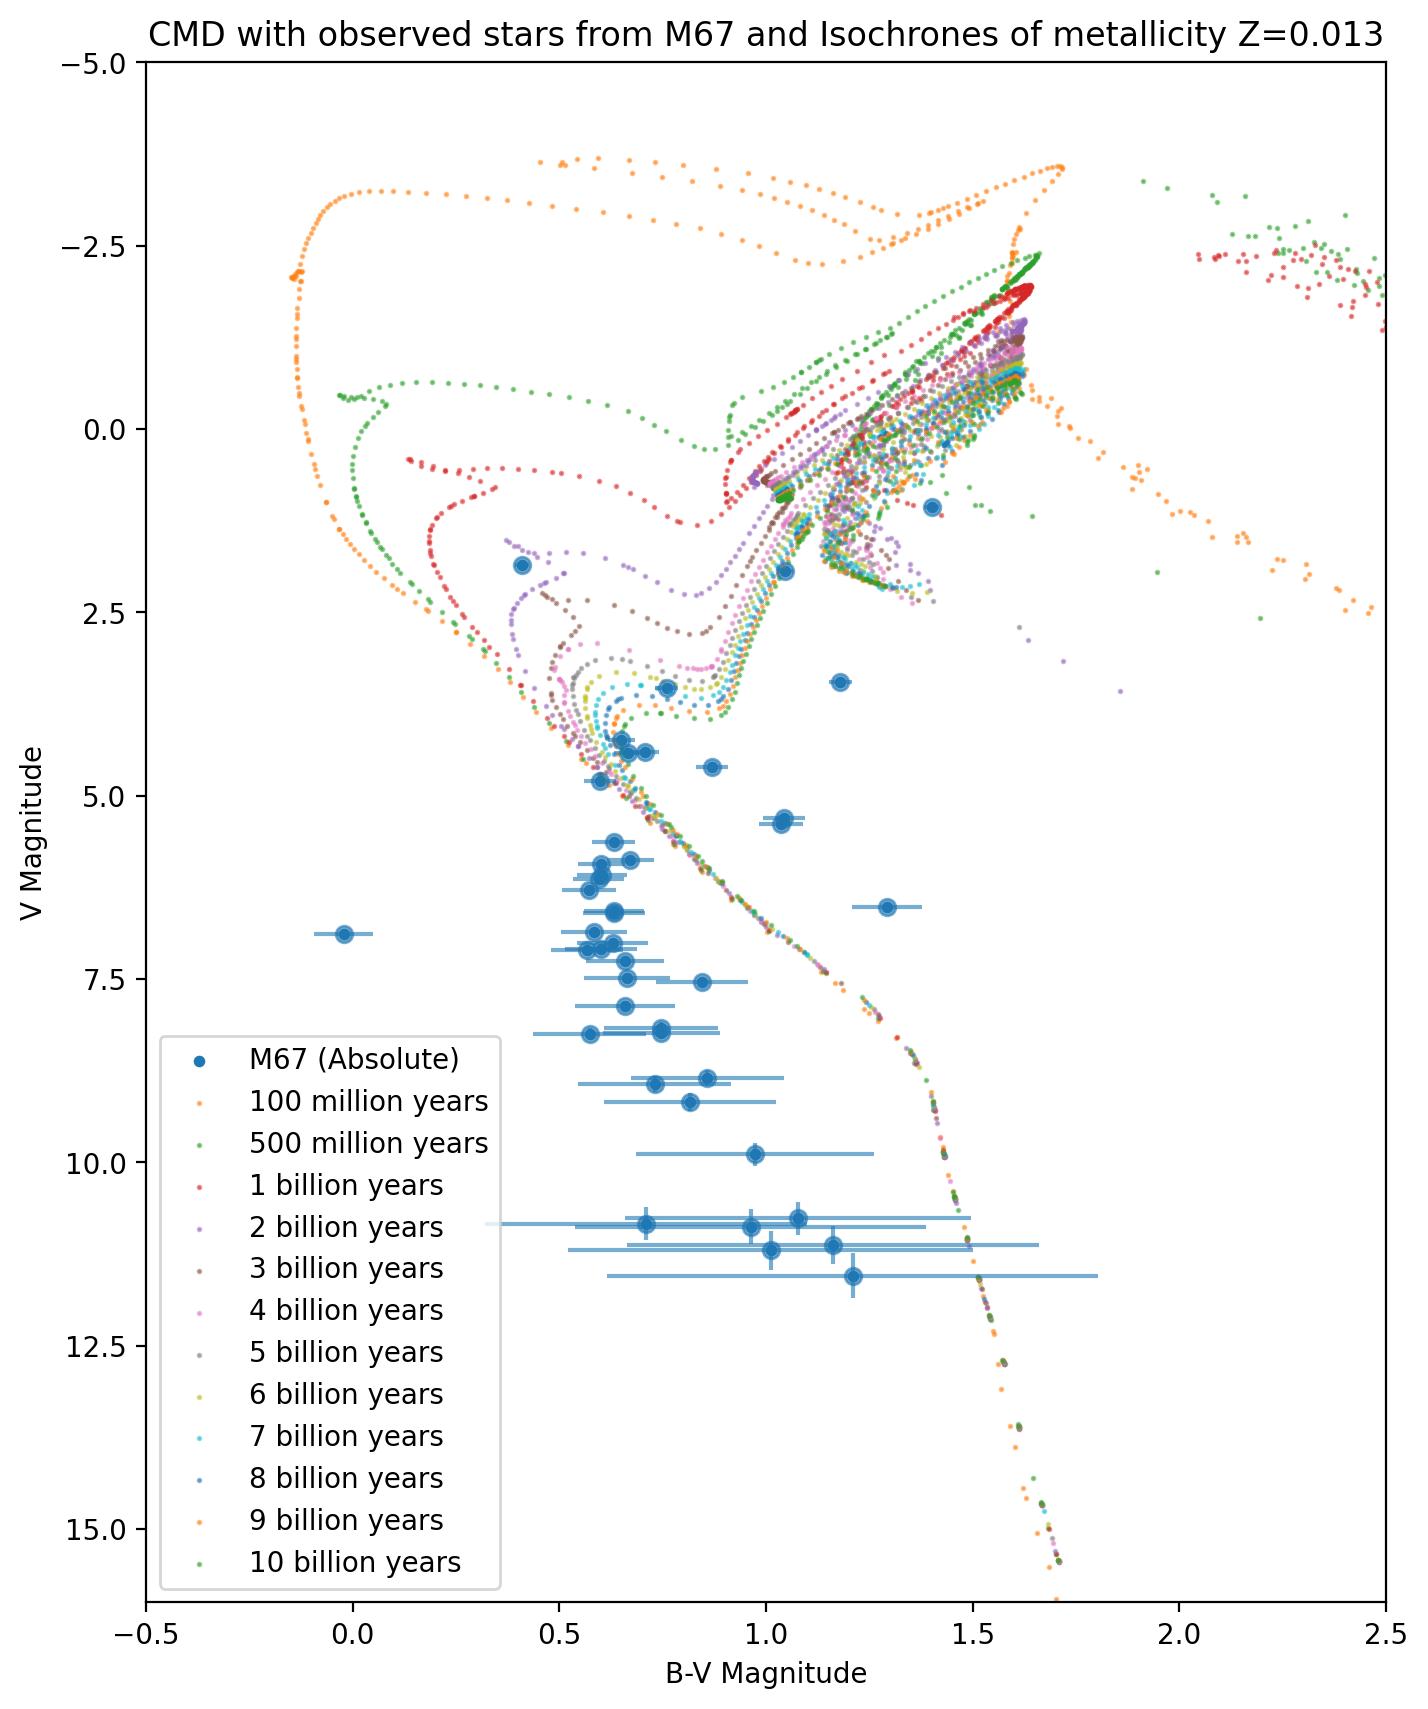

In [15]:
filepaths = [
    "Data/External Data/Isochrones/Chosen Isochrones/01bil.txt",
    "Data/External Data/Isochrones/Chosen Isochrones/05bil.txt",
    "Data/External Data/Isochrones/Chosen Isochrones/1bil.txt",
    "Data/External Data/Isochrones/Chosen Isochrones/2bil.txt",
    "Data/External Data/Isochrones/Chosen Isochrones/3bil.txt",
    "Data/External Data/Isochrones/Chosen Isochrones/4bil.txt",
    "Data/External Data/Isochrones/Chosen Isochrones/5bil.txt",
    "Data/External Data/Isochrones/Chosen Isochrones/6bil.txt",
    "Data/External Data/Isochrones/Chosen Isochrones/7bil.txt",
    "Data/External Data/Isochrones/Chosen Isochrones/8bil.txt",
    "Data/External Data/Isochrones/Chosen Isochrones/9bil.txt",
    "Data/External Data/Isochrones/Chosen Isochrones/10bil.txt",
]
isochrones = []
isochrone_years = [ "100 million", 
                    "500 million", 
                    "1 billion",
                    "2 billion", 
                    "3 billion", 
                    "4 billion", 
                    "5 billion", 
                    "6 billion", 
                    "7 billion",
                    "8 billion", 
                    "9 billion", 
                    "10 billion", 
                  ]

for file in filepaths:
    isochrones.append(np.transpose(np.loadtxt(file, skiprows=15)))

# Plot V Magnitude vs. B-V (This is the one to use because we only have magnitudes for our m67 values)
def plot_bv_v_cmd(isochrones):
    for i in range(0, len(isochrones)):
        isochrone = isochrones[i]
        # isochrone[29] is B_mag, isochrone[30] is V_mag
        plt.scatter(isochrone[29][:-1] - isochrone[30][:-1], isochrone[30][:-1], s=1, alpha=0.5, label=f'{isochrone_years[i]} years')
    plt.xlabel('B-V Magnitude')
    plt.ylabel('V Magnitude')
    plt.gca().invert_yaxis()  # Reverse y-axis
    plt.legend()

plt.figure(figsize=(8, 10), dpi=200)
plt.title("CMD with observed stars from M67 and Isochrones of metallicity Z=0.013")
plt.scatter(m67_BV_abs_magnitudes, m67_V_abs_magnitudes, s=10, alpha=1, label="M67 (Absolute)")
plt.errorbar(m67_BV_abs_magnitudes, m67_V_abs_magnitudes, fmt='o', xerr=m67_BV_err, yerr=m67_V_magnitudes_err, alpha=0.6)
#plt.scatter(m67_B_magnitudes - m67_V_magnitudes, m67_V_magnitudes, s=4, alpha=0.7, label="M67 (Apparent)")
plot_bv_v_cmd(isochrones)
plt.xlim(-0.5, 2.5)
plt.ylim(16, -5)
plt.savefig('Data/Results/GRAPH.png', bbox_inches='tight')
plt.show()